## Rough

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [93]:
!pip install librosa
!pip install -q yt-dlp


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import librosa

In [ ]:
# wherever the file in your drive
df = pd.read_csv('/content/drive/MyDrive/2026APCalcBCproject/features_30_sec.csv')
print(df.shape)   # should say (1000, 59)
df.head()

(1000, 60)


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.wav,661794,0.350088,0.088757,0.130228,0.002827,1784.165850,129774.064525,2002.449060,85882.761315,...,52.420910,-1.690215,36.524071,-0.408979,41.597103,-2.303523,55.062923,1.221291,46.936035,blues
1,blues.00001.wav,661794,0.340914,0.094980,0.095948,0.002373,1530.176679,375850.073649,2039.036516,213843.755497,...,55.356403,-0.731125,60.314529,0.295073,48.120598,-0.283518,51.106190,0.531217,45.786282,blues
2,blues.00002.wav,661794,0.363637,0.085275,0.175570,0.002746,1552.811865,156467.643368,1747.702312,76254.192257,...,40.598766,-7.729093,47.639427,-1.816407,52.382141,-3.439720,46.639660,-2.231258,30.573025,blues
3,blues.00003.wav,661794,0.404785,0.093999,0.141093,0.006346,1070.106615,184355.942417,1596.412872,166441.494769,...,44.427753,-3.319597,50.206673,0.636965,37.319130,-0.619121,37.259739,-3.407448,31.949339,blues
4,blues.00004.wav,661794,0.308526,0.087841,0.091529,0.002303,1835.004266,343399.939274,1748.172116,88445.209036,...,86.099236,-5.454034,75.269707,-0.916874,53.613918,-4.404827,62.910812,-11.703234,55.195160,blues


In [ ]:
X = df.drop(['filename', 'label'], axis=1).values
le = LabelEncoder()
y = le.fit_transform(df['label'])   # genre names → numbers (0-9)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", len(X_train))

Training samples: 800


In [ ]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')   # 10 genre outputs
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,906 (222.29 KB)

 Trainable params: 56,906 (222.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.2763 - loss: 2.0948 - val_accuracy: 0.3800 - val_loss: 1.7937
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4412 - loss: 1.5841 - val_accuracy: 0.4650 - val_loss: 1.4539
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5412 - loss: 1.3044 - val_accuracy: 0.5450 - val_loss: 1.2280
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6112 - loss: 1.1070 - val_accuracy: 0.5700 - val_loss: 1.1185
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6438 - loss: 0.9767 - val_accuracy: 0.6250 - val_loss: 1.0459
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7000 - loss: 0.8798 - val_accuracy: 0.6200 - val_loss: 1.0298
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7138 - loss: 0.7735 - val_accuracy: 0.6300 - val_loss: 0.9960
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7450 - loss: 0.7404 - val_accuracy: 0.

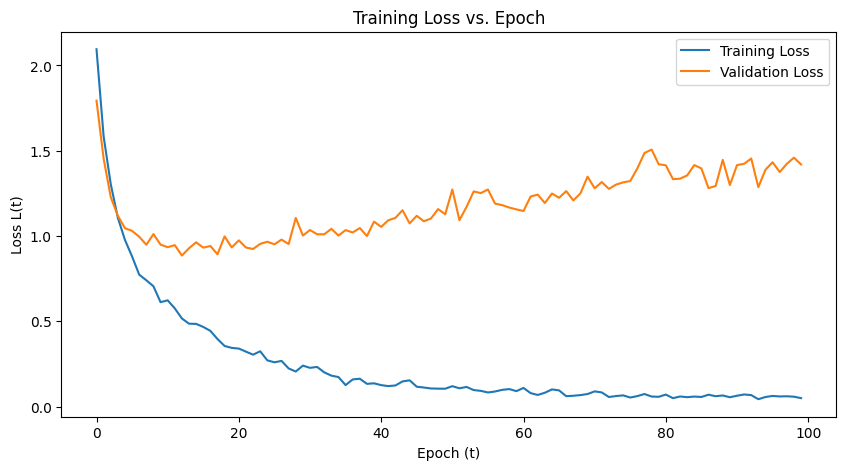

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch (t)')
plt.ylabel('Loss L(t)')
plt.title('Training Loss vs. Epoch')
plt.legend()
plt.savefig('loss_curve.png')
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc*100:.1f}%")
# Expect ~70-80% accuracy

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7350 - loss: 1.4193 
Test accuracy: 73.5%


In [ ]:
model.save('/content/drive/MyDrive/2026APCalcBCproject/genre_model.keras')
import pickle
with open('/content/drive/MyDrive/2026APCalcBCproject/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('/content/drive/MyDrive/2026APCalcBCproject/encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

In [ ]:
df.drop(['filename', 'label'], axis=1).columns.tolist()

['length',
 'chroma_stft_mean',
 'chroma_stft_var',
 'rms_mean',
 'rms_var',
 'spectral_centroid_mean',
 'spectral_centroid_var',
 'spectral_bandwidth_mean',
 'spectral_bandwidth_var',
 'rolloff_mean',
 'rolloff_var',
 'zero_crossing_rate_mean',
 'zero_crossing_rate_var',
 'harmony_mean',
 'harmony_var',
 'perceptr_mean',
 'perceptr_var',
 'tempo',
 'mfcc1_mean',
 'mfcc1_var',
 'mfcc2_mean',
 'mfcc2_var',
 'mfcc3_mean',
 'mfcc3_var',
 'mfcc4_mean',
 'mfcc4_var',
 'mfcc5_mean',
 'mfcc5_var',
 'mfcc6_mean',
 'mfcc6_var',
 'mfcc7_mean',
 'mfcc7_var',
 'mfcc8_mean',
 'mfcc8_var',
 'mfcc9_mean',
 'mfcc9_var',
 'mfcc10_mean',
 'mfcc10_var',
 'mfcc11_mean',
 'mfcc11_var',
 'mfcc12_mean',
 'mfcc12_var',
 'mfcc13_mean',
 'mfcc13_var',
 'mfcc14_mean',
 'mfcc14_var',
 'mfcc15_mean',
 'mfcc15_var',
 'mfcc16_mean',
 'mfcc16_var',
 'mfcc17_mean',
 'mfcc17_var',
 'mfcc18_mean',
 'mfcc18_var',
 'mfcc19_mean',
 'mfcc19_var',
 'mfcc20_mean',
 'mfcc20_var']

In [ ]:
# Download a YouTube video as MP3 (paste any YouTube URL)
!apt-get install -y nodejs
!yt-dlp -x --audio-format mp3 -o "/content/song.%(ext)s" "https://www.youtube.com/watch?v=dQw4w9WgXcQ"

def predict_genre(filepath):
    y_audio, sr = librosa.load(filepath, duration=30)

    features = []

    # Length (1)
    features.append(len(y_audio))

    # Chroma STFT (mean + var = 2)
    chroma = librosa.feature.chroma_stft(y=y_audio, sr=sr)
    features += [np.mean(chroma), np.var(chroma)]

    # RMS (mean + var = 2)
    rms = librosa.feature.rms(y=y_audio)
    features += [np.mean(rms), np.var(rms)]

    # Spectral Centroid (mean + var = 2)
    spec_cent = librosa.feature.spectral_centroid(y=y_audio, sr=sr)
    features += [np.mean(spec_cent), np.var(spec_cent)]

    # Spectral Bandwidth (mean + var = 2)
    spec_bw = librosa.feature.spectral_bandwidth(y=y_audio, sr=sr)
    features += [np.mean(spec_bw), np.var(spec_bw)]

    # Spectral Rolloff (mean + var = 2)
    rolloff = librosa.feature.spectral_rolloff(y=y_audio, sr=sr)
    features += [np.mean(rolloff), np.var(rolloff)]

    # Zero Crossing Rate (mean + var = 2)
    zcr = librosa.feature.zero_crossing_rate(y_audio)
    features += [np.mean(zcr), np.var(zcr)]

    # Harmony (mean + var = 2)
    harmony = librosa.effects.harmonic(y_audio)
    features += [np.mean(harmony), np.var(harmony)]

    # Perceptr (mean + var = 2)
    perceptr = librosa.effects.percussive(y_audio)
    features += [np.mean(perceptr), np.var(perceptr)]

    # Tempo (1)
    tempo, _ = librosa.beat.beat_track(y=y_audio, sr=sr)
    features.append(float(np.squeeze(tempo)))

    # MFCCs 1-20 (mean + var each = 40)
    mfccs = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=20)
    for coef in mfccs:
        features += [np.mean(coef), np.var(coef)]

    # 1+2+2+2+2+2+2+2+2+1+40 = 58
    print(f"Feature count: {len(features)}")

    features = np.array(features).reshape(1, -1)
    features_scaled = scaler.transform(features)
    pred = model.predict(features_scaled)
    genre = le.inverse_transform([np.argmax(pred)])[0]
    confidence = np.max(pred) * 100
    print(f"Predicted: {genre} ({confidence:.1f}% confidence)")
    return genre

# Try it
print(predict_genre("/content/song.mp3"))

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  javascript-common libc-ares2 libjs-highlight.js libnode72 nodejs-doc
Suggested packages:
  apache2 | lighttpd | httpd npm
The following NEW packages will be installed:
  javascript-common libc-ares2 libjs-highlight.js libnode72 nodejs nodejs-doc
0 upgraded, 6 newly installed, 0 to remove and 2 not upgraded.
Need to get 13.7 MB of archives.
After this operation, 54.0 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 javascript-common all 11+nmu1 [5,936 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libjs-highlight.js all 9.18.5+dfsg1-1 [367 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libc-ares2 amd64 1.18.1-1ubuntu0.22.04.3 [45.1 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 libnode72 amd64 12.22.9~dfsg-1ubuntu3.6 [10.8 MB]
G

L(t) = 1.8099 * e^(-0.1110t) + 0.0940
So L'(t) = -1.8099 * 0.1110 * e^(-0.1110t)
At epoch 10, learning rate = -0.0662 loss/epoch


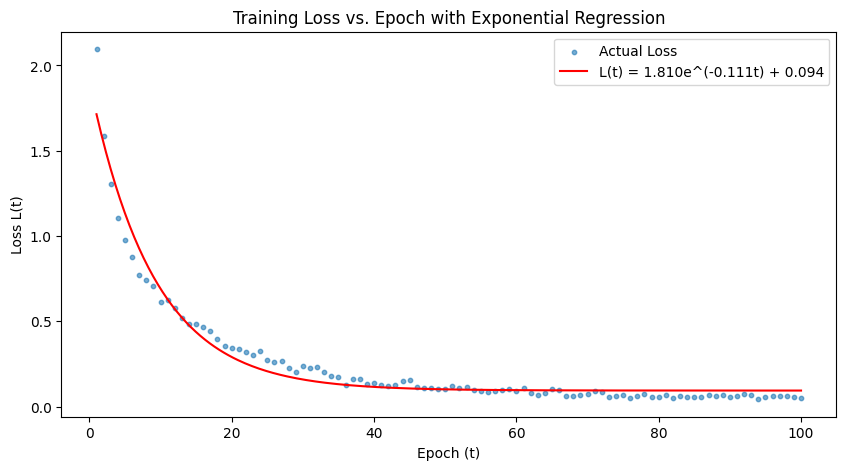

In [ ]:
from scipy.optimize import curve_fit

epochs = np.arange(1, len(history.history['loss']) + 1)
loss_vals = np.array(history.history['loss'])

# Code I have 0 clue how to interpret honestly

# Fit exponential decay: L(t) = a * e^(-bt) + c
def exp_decay(t, a, b, c):
    return a * np.exp(-b * t) + c

params, _ = curve_fit(exp_decay, epochs, loss_vals, p0=[1, 0.01, 0.5], maxfev=5000)
a, b, c = params
print(f"L(t) = {a:.4f} * e^(-{b:.4f}t) + {c:.4f}")
print(f"So L'(t) = -{a:.4f} * {b:.4f} * e^(-{b:.4f}t)")
print(f"At epoch 10, learning rate = {-a*b*np.exp(-b*10):.4f} loss/epoch")

# Plot with regression overlaid
t_smooth = np.linspace(1, 100, 300)
plt.figure(figsize=(10,5))
plt.scatter(epochs, loss_vals, s=10, label='Actual Loss', alpha=0.6)
plt.plot(t_smooth, exp_decay(t_smooth, *params), 'r-', label=f'L(t) = {a:.3f}e^(-{b:.3f}t) + {c:.3f}')
plt.xlabel('Epoch (t)')
plt.ylabel('Loss L(t)')
plt.title('Training Loss vs. Epoch with Exponential Regression')
plt.legend()
plt.savefig('loss_regression.png', dpi=150)
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/2026APCalcBCproject/genre_model.keras")
import pickle
with open("/content/drive/MyDrive/2026APCalcBCproject/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("/content/drive/MyDrive/2026APCalcBCproject/le.pkl", "wb") as f:
    pickle.dump(le, f)
import json
with open("/content/drive/MyDrive/2026APCalcBCproject/history.json", "w") as f:
    json.dump(history.history, f)
print("Saved.")


Saved.


## DEMO

In [94]:
!pip install yt-dlp -q
!apt-get install -y nodejs -q

Reading package lists...
Building dependency tree...
Reading state information...
nodejs is already the newest version (12.22.9~dfsg-1ubuntu3.6).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [95]:
import tensorflow as tf, pickle, json, numpy as np

model  = tf.keras.models.load_model("/content/drive/MyDrive/2026APCalcBCproject/genre_model.keras")
scaler = pickle.load(open("/content/drive/MyDrive/2026APCalcBCproject/scaler.pkl", "rb"))
le     = pickle.load(open("/content/drive/MyDrive/2026APCalcBCproject/le.pkl", "rb"))
history_data = json.load(open("/content/drive/MyDrive/2026APCalcBCproject/history.json"))

class FakeHistory:
    pass
history = FakeHistory()
history.history = history_data

print("Loaded successfully.")

Loaded successfully.


In [96]:
YOUTUBE_URL = "https://www.youtube.com/watch?v=ElN_4vUvTPs"
import os

output_path = "/content/demo_song.mp3"
if os.path.exists(output_path):
    os.remove(output_path)

!yt-dlp -f "bestaudio/best" --extract-audio --audio-format mp3 --audio-quality 0 \
  -o "/content/demo_song.%(ext)s" "{YOUTUBE_URL}"

if not os.path.exists(output_path):
    raise FileNotFoundError("Download failed — see error above")

print(f"File size: {os.path.getsize(output_path) / 1024:.1f} KB")
print("Audio ready:", output_path)

[youtube] Extracting URL: https://www.youtube.com/watch?v=ElN_4vUvTPs
[youtube] ElN_4vUvTPs: Downloading webpage
[youtube] ElN_4vUvTPs: Downloading android vr player API JSON
[youtube] ElN_4vUvTPs: Downloading player 4f38b487-main
[youtube] [jsc:deno] Solving JS challenges using deno
[youtube] ElN_4vUvTPs: Downloading m3u8 information
[info] ElN_4vUvTPs: Downloading 1 format(s): 251
[download] Destination: /content/demo_song.webm
[download] 100% of    4.05MiB in 00:00:00 at 79.62MiB/s
[ExtractAudio] Destination: /content/demo_song.mp3
Deleting original file /content/demo_song.webm (pass -k to keep)
File size: 8252.7 KB
Audio ready: /content/demo_song.mp3


Sampling rate : 22,050 Hz
Total samples : 661,500  (30 seconds)

The raw audio signal is an array of amplitude values sampled 22,050
times per second. A 30-second clip produces 661,500 data points.
The network cannot learn directly from this, features must be extracted first.


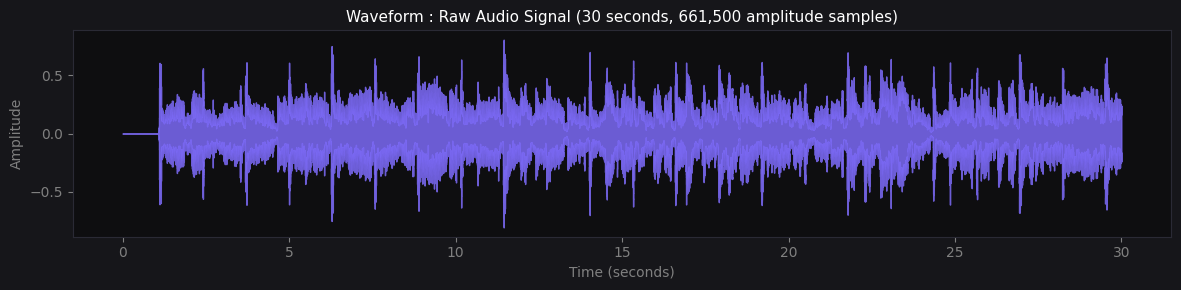

In [97]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

y_audio, sr = librosa.load(output_path, duration=30)

print(f"Sampling rate : {sr:,} Hz")
print(f"Total samples : {len(y_audio):,}  ({len(y_audio)/sr:.0f} seconds)")
print()
print("The raw audio signal is an array of amplitude values sampled 22,050")
print("times per second. A 30-second clip produces 661,500 data points.")
print("The network cannot learn directly from this, features must be extracted first.")

fig, ax = plt.subplots(figsize=(12, 3))
librosa.display.waveshow(y_audio, sr=sr, ax=ax, color="#7c6af7", alpha=0.85)
ax.set_title("Waveform : Raw Audio Signal (30 seconds, 661,500 amplitude samples)", fontsize=11)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude")
ax.set_facecolor("#0e0e10")
fig.patch.set_facecolor("#16161a")
ax.tick_params(colors="gray")
ax.xaxis.label.set_color("gray")
ax.yaxis.label.set_color("gray")
ax.title.set_color("white")
for spine in ax.spines.values():
    spine.set_edgecolor("#2a2a35")
plt.tight_layout()
plt.show()

Features extracted: 58 / 58

  Feature                     Value   Description
  ---------------------- ----------   --------------------------------
  Tempo                     92.2852   Rhythmic pace in BPM
  Spectral Centroid       2641.1000   Average frequency / brightness
  RMS Energy                 0.1148   Overall loudness
  Zero Crossing Rate         0.0782   Signal noisiness
  Chroma                     0.3696   Harmonic pitch-class content
  Spectral Rolloff        6363.8365   Frequency below 85% of energy
  MFCC-1                  -167.6519   Spectral shape / loudness proxy
  MFCC-2                    78.2784   Spectral slope

These 8 values, plus 50 more MFCC coefficients, form the 58-dimensional
input vector that gets passed into the neural network.


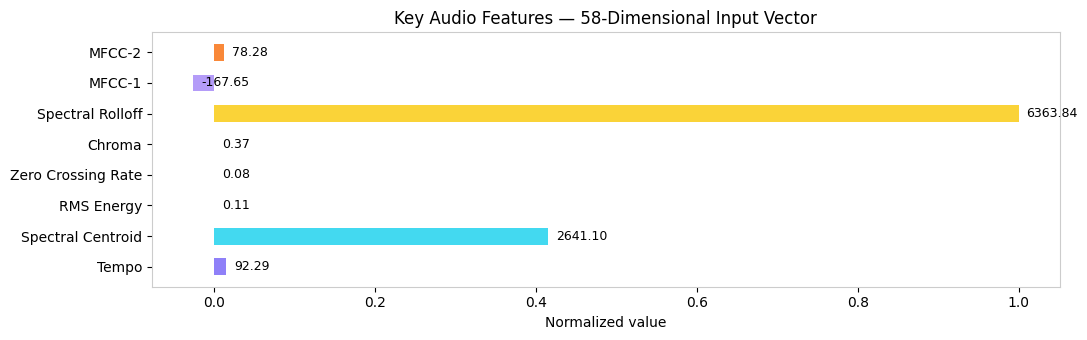

In [98]:
import numpy as np

features_dict = {}
features_dict["length"] = len(y_audio)

chroma = librosa.feature.chroma_stft(y=y_audio, sr=sr)
features_dict["chroma_stft_mean"] = np.mean(chroma)
features_dict["chroma_stft_var"]  = np.var(chroma)

rms = librosa.feature.rms(y=y_audio)
features_dict["rms_mean"] = np.mean(rms)
features_dict["rms_var"]  = np.var(rms)

spec_cent = librosa.feature.spectral_centroid(y=y_audio, sr=sr)
features_dict["spectral_centroid_mean"] = np.mean(spec_cent)
features_dict["spectral_centroid_var"]  = np.var(spec_cent)

spec_bw = librosa.feature.spectral_bandwidth(y=y_audio, sr=sr)
features_dict["spectral_bandwidth_mean"] = np.mean(spec_bw)
features_dict["spectral_bandwidth_var"]  = np.var(spec_bw)

rolloff = librosa.feature.spectral_rolloff(y=y_audio, sr=sr)
features_dict["rolloff_mean"] = np.mean(rolloff)
features_dict["rolloff_var"]  = np.var(rolloff)

zcr = librosa.feature.zero_crossing_rate(y_audio)
features_dict["zero_crossing_rate_mean"] = np.mean(zcr)
features_dict["zero_crossing_rate_var"]  = np.var(zcr)

harmony = librosa.effects.harmonic(y_audio)
features_dict["harmony_mean"] = np.mean(harmony)
features_dict["harmony_var"]  = np.var(harmony)

perceptr = librosa.effects.percussive(y_audio)
features_dict["perceptr_mean"] = np.mean(perceptr)
features_dict["perceptr_var"]  = np.var(perceptr)

tempo, _ = librosa.beat.beat_track(y=y_audio, sr=sr)
features_dict["tempo"] = float(np.squeeze(tempo))

mfccs = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=20)
for i, coef in enumerate(mfccs, 1):
    features_dict[f"mfcc{i}_mean"] = np.mean(coef)
    features_dict[f"mfcc{i}_var"]  = np.var(coef)

print(f"Features extracted: {len(features_dict)} / 58")
print()

KEY = {
    "tempo":                   ("Tempo",               "Rhythmic pace in BPM"),
    "spectral_centroid_mean":  ("Spectral Centroid",   "Average frequency / brightness"),
    "rms_mean":                ("RMS Energy",          "Overall loudness"),
    "zero_crossing_rate_mean": ("Zero Crossing Rate",  "Signal noisiness"),
    "chroma_stft_mean":        ("Chroma",              "Harmonic pitch-class content"),
    "rolloff_mean":            ("Spectral Rolloff",    "Frequency below 85% of energy"),
    "mfcc1_mean":              ("MFCC-1",              "Spectral shape / loudness proxy"),
    "mfcc2_mean":              ("MFCC-2",              "Spectral slope"),
}
print(f"  {'Feature':<22} {'Value':>10}   Description")
print(f"  {'-'*22} {'-'*10}   {'-'*32}")
for key, (name, desc) in KEY.items():
    print(f"  {name:<22} {features_dict[key]:>10.4f}   {desc}")

print()
print("These 8 values, plus 50 more MFCC coefficients, form the 58-dimensional")
print("input vector that gets passed into the neural network.")

# Bar chart
fig, ax = plt.subplots(figsize=(11, 3.5))
names  = [v[0] for v in KEY.values()]
values = [features_dict[k] for k in KEY]
max_v  = max(abs(v) for v in values) or 1
norm   = [v / max_v for v in values]
colors = ["#7c6af7","#22d3ee","#f472b6","#fb923c","#4ade80","#facc15","#a78bf7","#f97316"]

bars = ax.barh(names, norm, color=colors, alpha=0.85, height=0.55)
ax.set_xlabel("Normalized value", color="black")
ax.set_title("Key Audio Features — 58-Dimensional Input Vector", color="black")
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.tick_params(colors="black", labelsize=10)
ax.xaxis.label.set_color("black")
for spine in ax.spines.values():
    spine.set_edgecolor("#cccccc")
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", color="black", fontsize=9)
plt.tight_layout()
plt.savefig("/content/features.png", dpi=150, bbox_inches="tight")
plt.show()

Architecture:  Input(58) -> Dense(256, ReLU) -> Dense(128, ReLU) -> Dense(64, ReLU) -> Output(10, Softmax)

  Layer 1  Dense(256)  102 / 256 neurons active   mean = 0.4694
  Layer 2  Dense(128)   68 / 128 neurons active   mean = 0.5669
  Layer 3  Dense( 64)   54 /  64 neurons active   mean = 1.3395

ReLU activation:  f(x) = max(0, x)
Neurons with a negative pre-activation output zero and do not contribute
to the prediction. Only the active neurons carry information forward.


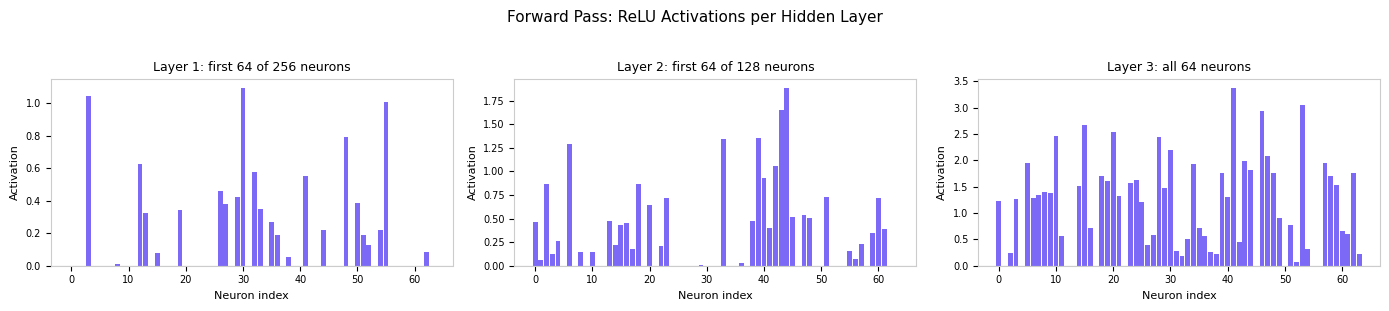

In [99]:
# Step 3: Forward pass through the network
import numpy as np
import matplotlib.pyplot as plt

feature_vector = np.array(list(features_dict.values())).reshape(1, -1)
feature_scaled = scaler.transform(feature_vector)

# Run input through each layer manually
inp_tensor = feature_scaled.astype("float32")
act_256 = model.layers[0](inp_tensor).numpy()[0]   # Dense 256
act_128 = model.layers[2](act_256.reshape(1,-1)).numpy()[0]   # Dense 128
act_64  = model.layers[4](act_128.reshape(1,-1)).numpy()[0]   # Dense 64

print("Architecture:  Input(58) -> Dense(256, ReLU) -> Dense(128, ReLU) -> Dense(64, ReLU) -> Output(10, Softmax)")
print()
print(f"  Layer 1  Dense(256)  {np.sum(act_256 > 0):>3} / 256 neurons active   mean = {np.mean(act_256[act_256>0]):.4f}")
print(f"  Layer 2  Dense(128)  {np.sum(act_128 > 0):>3} / 128 neurons active   mean = {np.mean(act_128[act_128>0]):.4f}")
print(f"  Layer 3  Dense( 64)   {np.sum(act_64 > 0):>2} /  64 neurons active   mean = {np.mean(act_64[act_64>0]):.4f}")
print()
print("ReLU activation:  f(x) = max(0, x)")
print("Neurons with a negative pre-activation output zero and do not contribute")
print("to the prediction. Only the active neurons carry information forward.")

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
datasets = [act_256[:64], act_128[:64], act_64]
titles   = [
    "Layer 1: first 64 of 256 neurons",
    "Layer 2: first 64 of 128 neurons",
    "Layer 3: all 64 neurons",
]
for ax, data, title in zip(axes, datasets, titles):
    bar_colors = ["#7c6af7" if v > 0 else "#e5e5e5" for v in data]
    ax.bar(range(len(data)), data, color=bar_colors, width=0.85)
    ax.axhline(0, color="#aaaaaa", linewidth=0.8)
    ax.set_title(title, fontsize=9, color="black")
    ax.set_xlabel("Neuron index", fontsize=8, color="black")
    ax.set_ylabel("Activation", fontsize=8, color="black")
    ax.set_facecolor("white")
    ax.tick_params(colors="black", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#cccccc")
fig.patch.set_facecolor("white")
plt.suptitle("Forward Pass: ReLU Activations per Hidden Layer", color="black", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("/content/activations.png", dpi=150, bbox_inches="tight")
plt.show()

Softmax:  P(class_i) = e^(z_i) / sum(e^(z_j))  for all j
Converts raw output scores into probabilities that sum to exactly 1.0

  Genre         Probability  Bar
  ------------  -----------  --------------------------------
  rock               37.7%  ██████████████  <-- prediction
  jazz               27.4%  ██████████
  pop                17.1%  ██████
  disco               9.8%  ███
  reggae              3.5%  █
  country             2.5%  
  hiphop              2.0%  
  blues               0.1%  
  classical           0.0%  
  metal               0.0%  

  Predicted genre : ROCK
  Confidence      : 37.7%


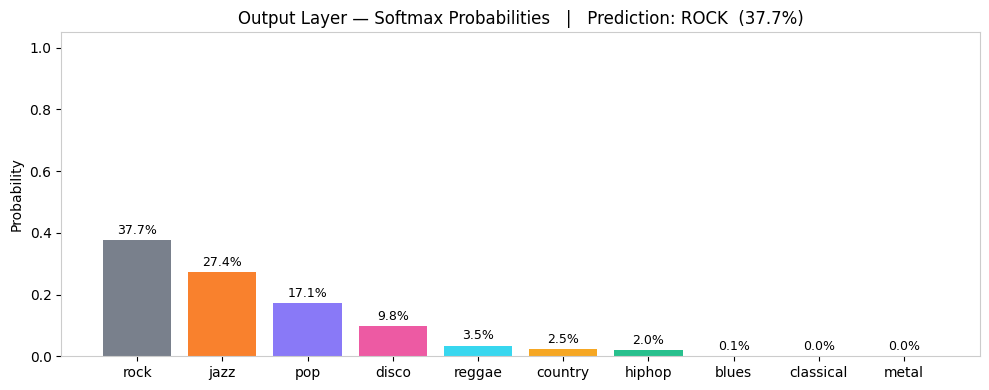

In [100]:
# Step 4 - Softmax output and final prediction
GENRES = ["blues","classical","country","disco","hiphop","jazz","metal","pop","reggae","rock"]

final       = model.predict(feature_scaled, verbose=0)[0]
probs       = dict(zip(GENRES, final))
sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)
top_genre, top_conf = sorted_probs[0]

print("Softmax:  P(class_i) = e^(z_i) / sum(e^(z_j))  for all j")
print("Converts raw output scores into probabilities that sum to exactly 1.0")
print()
print(f"  {'Genre':<12}  {'Probability':>11}  Bar")
print(f"  {'-'*12}  {'-'*11}  {'-'*32}")
for genre, prob in sorted_probs:
    bar    = chr(9608) * int(prob * 38)
    marker = "  <-- prediction" if genre == top_genre else ""
    print(f"  {genre:<12}  {prob:>10.1%}  {bar}{marker}")

print()
print(f"  Predicted genre : {top_genre.upper()}")
print(f"  Confidence      : {top_conf * 100:.1f}%")

COLORS = {
    "blues":"#3b82f6","classical":"#8b5cf6","country":"#f59e0b",
    "disco":"#ec4899","hiphop":"#10b981","jazz":"#f97316",
    "metal":"#ef4444","pop":"#7c6af7","reggae":"#22d3ee","rock":"#6b7280",
}
fig, ax = plt.subplots(figsize=(10, 4))
gs = [g for g,_ in sorted_probs]
ps = [p for _,p in sorted_probs]
bar_colors = [COLORS.get(g, "#7c6af7") if g == top_genre
              else COLORS.get(g, "#cccccc") + "99" for g in gs]
bars = ax.bar(gs, ps, color=bar_colors, alpha=0.9)
ax.set_ylabel("Probability", color="black")
ax.set_ylim(0, 1.05)
ax.set_title(f"Output Layer — Softmax Probabilities   |   Prediction: {top_genre.upper()}  ({top_conf*100:.1f}%)",
             color="black")
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.tick_params(colors="black")
ax.yaxis.label.set_color("black")
for spine in ax.spines.values():
    spine.set_edgecolor("#cccccc")
for bar, prob in zip(bars, ps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{prob:.1%}", ha="center", va="bottom", color="black", fontsize=9)
plt.tight_layout()
plt.savefig("/content/softmax.png", dpi=150, bbox_inches="tight")
plt.show()

GRADIENT DESCENT
--------------------------------------------------
After every training batch, each weight is updated:

   w_new = w_old - lr * (dL/dw)

dL/dw is the partial derivative of the loss with respect
to that weight. It tells the network which direction
increases loss, so the weight moves the opposite way.
This is identical to using f'(x) to locate a minimum.

BACKPROPAGATION — CHAIN RULE
--------------------------------------------------
A weight in layer 1 affects the loss through layers 2, 3, 4.
To compute its gradient, multiply local derivatives across layers:

   dL/dw1 = (dL/da4) * (da4/da3) * (da3/da2) * (da2/dw1)

Each term is the derivative of one layer's output with respect
to its input. This is the chain rule applied across 4 layers.

SIGMOID DERIVATIVE — QUOTIENT RULE
--------------------------------------------------
   sigma(x)  = 1 / (1 + e^(-x))
   sigma'(x) = sigma(x) * (1 - sigma(x))

Derived by applying the quotient rule to 1 / (1 + e^(-x)).
Used during bac

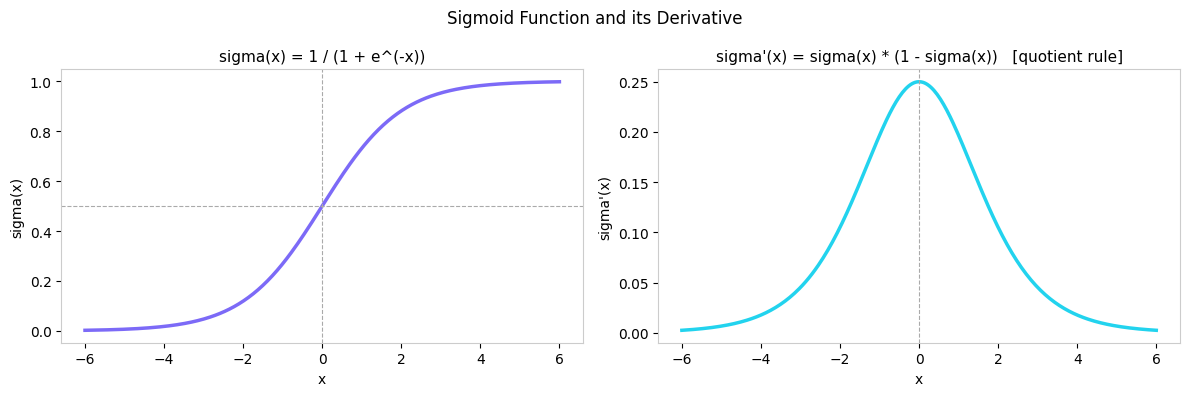

In [101]:
# Calculus connections

import numpy as np
import matplotlib.pyplot as plt

# --- Gradient Descent ---
print("GRADIENT DESCENT")
print("-" * 50)
print("After every training batch, each weight is updated:")
print()
print("   w_new = w_old - lr * (dL/dw)")
print()
print("dL/dw is the partial derivative of the loss with respect")
print("to that weight. It tells the network which direction")
print("increases loss, so the weight moves the opposite way.")
print("This is identical to using f'(x) to locate a minimum.")
print()

# --- Backpropagation ---
print("BACKPROPAGATION — CHAIN RULE")
print("-" * 50)
print("A weight in layer 1 affects the loss through layers 2, 3, 4.")
print("To compute its gradient, multiply local derivatives across layers:")
print()
print("   dL/dw1 = (dL/da4) * (da4/da3) * (da3/da2) * (da2/dw1)")
print()
print("Each term is the derivative of one layer's output with respect")
print("to its input. This is the chain rule applied across 4 layers.")
print()

# --- Sigmoid ---
print("SIGMOID DERIVATIVE — QUOTIENT RULE")
print("-" * 50)
print("   sigma(x)  = 1 / (1 + e^(-x))")
print("   sigma'(x) = sigma(x) * (1 - sigma(x))")
print()
print("Derived by applying the quotient rule to 1 / (1 + e^(-x)).")
print("Used during backpropagation to compute each neuron's gradient.")

# Plot sigmoid and derivative
x = np.linspace(-6, 6, 300)
sig   = 1 / (1 + np.exp(-x))
dsig  = sig * (1 - sig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(x, sig, color="#7c6af7", linewidth=2.5)
axes[0].axhline(0.5, color="#aaaaaa", linestyle="--", linewidth=0.8)
axes[0].axvline(0,   color="#aaaaaa", linestyle="--", linewidth=0.8)
axes[0].set_title("sigma(x) = 1 / (1 + e^(-x))", color="black", fontsize=11)
axes[0].set_xlabel("x", color="black")
axes[0].set_ylabel("sigma(x)", color="black")

axes[1].plot(x, dsig, color="#22d3ee", linewidth=2.5)
axes[1].axvline(0, color="#aaaaaa", linestyle="--", linewidth=0.8)
axes[1].set_title("sigma'(x) = sigma(x) * (1 - sigma(x))   [quotient rule]",
                  color="black", fontsize=11)
axes[1].set_xlabel("x", color="black")
axes[1].set_ylabel("sigma'(x)", color="black")

for ax in axes:
    ax.set_facecolor("white")
    ax.tick_params(colors="black")
    for spine in ax.spines.values():
        spine.set_edgecolor("#cccccc")
fig.patch.set_facecolor("white")
plt.suptitle("Sigmoid Function and its Derivative", color="black", fontsize=12)
plt.tight_layout()
plt.savefig("/content/sigmoid.png", dpi=150, bbox_inches="tight")
plt.show()

LOSS REGRESSION
--------------------------------------------------
Model   :  L(t) = a * e^(-bt) + c
Fit     :  L(t) = 1.8099 * e^(-0.1110t) + 0.0940
Deriv   :  L'(t) = -0.200842 * e^(-0.1110t)

   Epoch       L(t)           L'(t)
  ------  ---------  --------------
       1     1.7139       -0.179747 loss/epoch
       5     1.1332       -0.115317 loss/epoch
      10     0.6907       -0.066211 loss/epoch
      20     0.2907       -0.021827 loss/epoch
      50     0.1011       -0.000782 loss/epoch
     100     0.0941       -0.000003 loss/epoch

At epoch 10, the model was improving at a rate of
0.066211 loss per epoch.
As t approaches infinity, loss approaches 0.0940 (irreducible error).


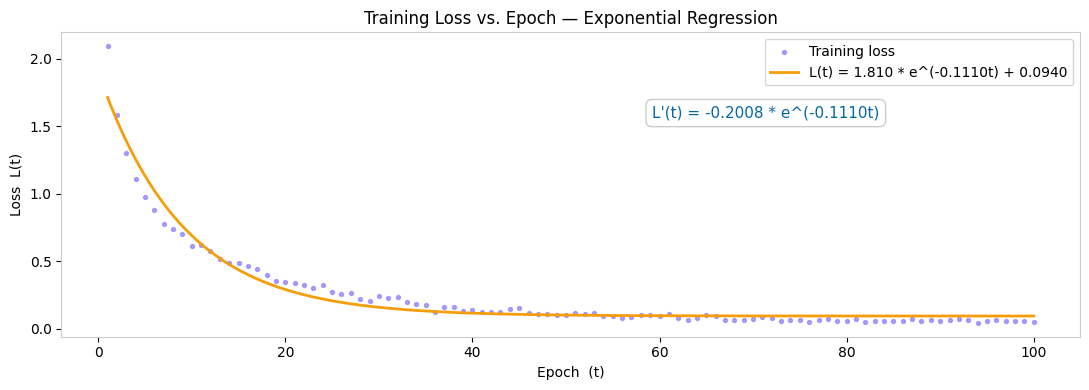

In [102]:
# Loss regression
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

loss_vals = np.array(history.history["loss"])
epochs    = np.arange(1, len(loss_vals) + 1)

def exp_decay(t, a, b, c):
    return a * np.exp(-b * t) + c

params, _ = curve_fit(exp_decay, epochs, loss_vals,
                      p0=[1.0, 0.03, 0.3], maxfev=10000)
a, b, c = params
t_smooth = np.linspace(1, len(loss_vals), 400)

print("LOSS REGRESSION")
print("-" * 50)
print(f"Model   :  L(t) = a * e^(-bt) + c")
print(f"Fit     :  L(t) = {a:.4f} * e^(-{b:.4f}t) + {c:.4f}")
print(f"Deriv   :  L'(t) = -{a*b:.6f} * e^(-{b:.4f}t)")
print()
print(f"  {'Epoch':>6}  {'L(t)':>9}  {'L\'(t)':>14}")
print(f"  {'-'*6}  {'-'*9}  {'-'*14}")
for t_val in [1, 5, 10, 20, 50, int(len(loss_vals))]:
    lt  = exp_decay(t_val, a, b, c)
    dlt = -a * b * np.exp(-b * t_val)
    print(f"  {t_val:>6}  {lt:>9.4f}  {dlt:>14.6f} loss/epoch")

print()
print(f"At epoch 10, the model was improving at a rate of")
print(f"{abs(-a*b*np.exp(-b*10)):.6f} loss per epoch.")
print(f"As t approaches infinity, loss approaches {c:.4f} (irreducible error).")

fig, ax = plt.subplots(figsize=(11, 4))
ax.scatter(epochs, loss_vals, s=8, color="#7c6af7", alpha=0.6,
           label="Training loss", zorder=2)
ax.plot(t_smooth, exp_decay(t_smooth, a, b, c),
        color="#f59e0b", linewidth=2,
        label=f"L(t) = {a:.3f} * e^(-{b:.4f}t) + {c:.4f}", zorder=3)
ax.set_xlabel("Epoch  (t)", color="black")
ax.set_ylabel("Loss  L(t)", color="black")
ax.set_title("Training Loss vs. Epoch — Exponential Regression", color="black")
ax.legend(facecolor="white", edgecolor="#cccccc",
          labelcolor="black", fontsize=10)
ax.text(0.58, 0.72,
        f"L'(t) = -{a*b:.4f} * e^(-{b:.4f}t)",
        transform=ax.transAxes, color="#0369a1", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cccccc"))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
ax.tick_params(colors="black")
for spine in ax.spines.values():
    spine.set_edgecolor("#cccccc")
plt.tight_layout()
plt.savefig("/content/loss_regression.png", dpi=150, bbox_inches="tight")
plt.show()

In [103]:
import os
print(os.listdir("/content/drive/MyDrive/"))
print(os.listdir("/content/drive/MyDrive/2026APCalcBCproject/"))

['2026APCalcBCproject', 'Career', 'Colab Notebooks']
['demo.ipynb', 'history.json', 'le.pkl', 'scaler.pkl', 'encoder.pkl', 'Copy of Copy of Machine Learning for Music Genre Classification.ipynb', 'features_30_sec.csv', 'genre_model.keras', 'Final Project_ Just Because; Neural Network Music Genre Classifier.pdf', 'Untitled document.gdoc', 'Final Project_ Just Because; Neural Network Music Genre Classifier.gdoc', 'www.youtube.com_cookies.txt']


In [104]:
# (AI)
# ── YOUTUBE DOWNLOAD TEST (no cookies) ────────────────────────────────
import os, subprocess

TEST_URL = "https://www.youtube.com/watch?v=ElN_4vUvTPs"
test_path = "/content/test_download.mp3"

if os.path.exists(test_path):
    os.remove(test_path)

result = os.system(f'yt-dlp -f "bestaudio/best" --extract-audio --audio-format mp3 -o "/content/test_download.%(ext)s" "{TEST_URL}" -q --no-warnings 2>/dev/null')

if os.path.exists(test_path):
    print("✅ No cookies needed — YouTube downloads work fine on this session's IP.")
    print(f"   File size: {os.path.getsize(test_path)/1024:.1f} KB")
    os.remove(test_path)
else:
    print("❌ Cookies required — this session's IP is flagged by YouTube.")
    print("   Keep the cookies fallback cell in your notebook.")

✅ No cookies needed — YouTube downloads work fine on this session's IP.
   File size: 4387.6 KB
